# Show water phantom images

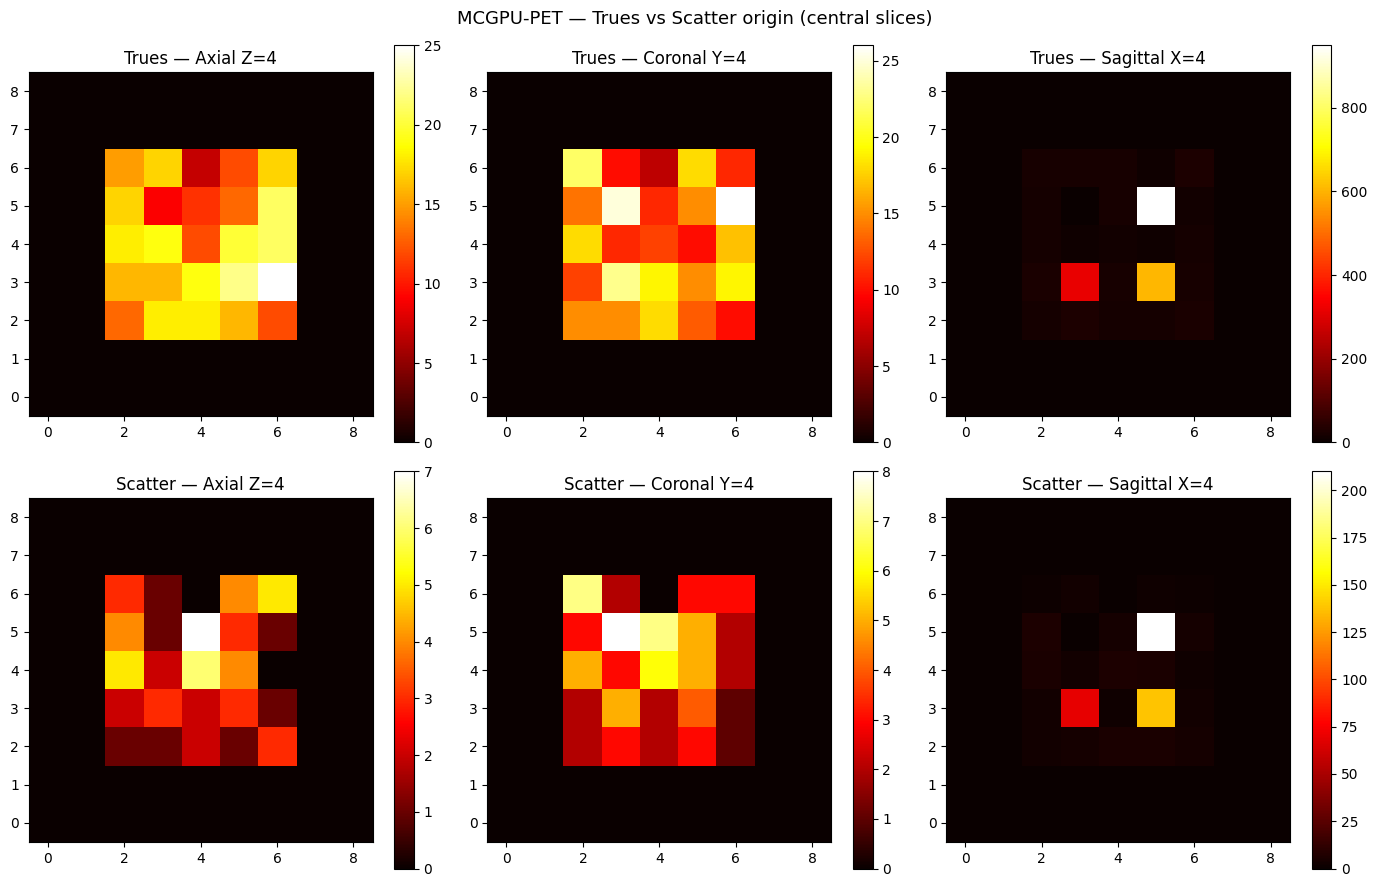

In [3]:
import numpy as np
import gzip
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load compressed files ──────────────────────────────────────────────
with gzip.open("image_Trues.raw.gz",   "rb") as f:
    trues   = np.frombuffer(f.read(), dtype=np.int32).reshape((9, 9, 9))
with gzip.open("image_Scatter.raw.gz", "rb") as f:
    scatter = np.frombuffer(f.read(), dtype=np.int32).reshape((9, 9, 9))

# Sinogram: 147 radial × 168 angular × 1293 slices (from the sim output)
with gzip.open("sinogram_Trues.raw.gz",   "rb") as f:
    sino_trues   = np.frombuffer(f.read(), dtype=np.int32).reshape((1293, 168, 147))
with gzip.open("sinogram_Scatter.raw.gz", "rb") as f:
    sino_scatter = np.frombuffer(f.read(), dtype=np.int32).reshape((1293, 168, 147))

# ── Figure 1: Voxel images (where did coincidences come from?) ─────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("MCGPU-PET — Trues vs Scatter origin (central slices)", fontsize=13)

for row, (vol, label) in enumerate([(trues, "Trues"), (scatter, "Scatter")]):
    for col, (sl, title) in enumerate([
        (vol[:, :, 4], "Axial Z=4"),
        (vol[:, 4, :], "Coronal Y=4"),
        (vol[4, :, :], "Sagittal X=4"),
    ]):
        ax = axes[row][col]
        im = ax.imshow(sl, cmap="hot", interpolation="nearest", origin="lower")
        ax.set_title(f"{label} — {title}")
        plt.colorbar(im, ax=ax)

plt.tight_layout()
# plt.savefig("voxel_images.png", dpi=150, bbox_inches="tight")
plt.show()

# Show sinograms

Trues summed max: 5, total: 3809
Scatter summed max: 3, total: 758


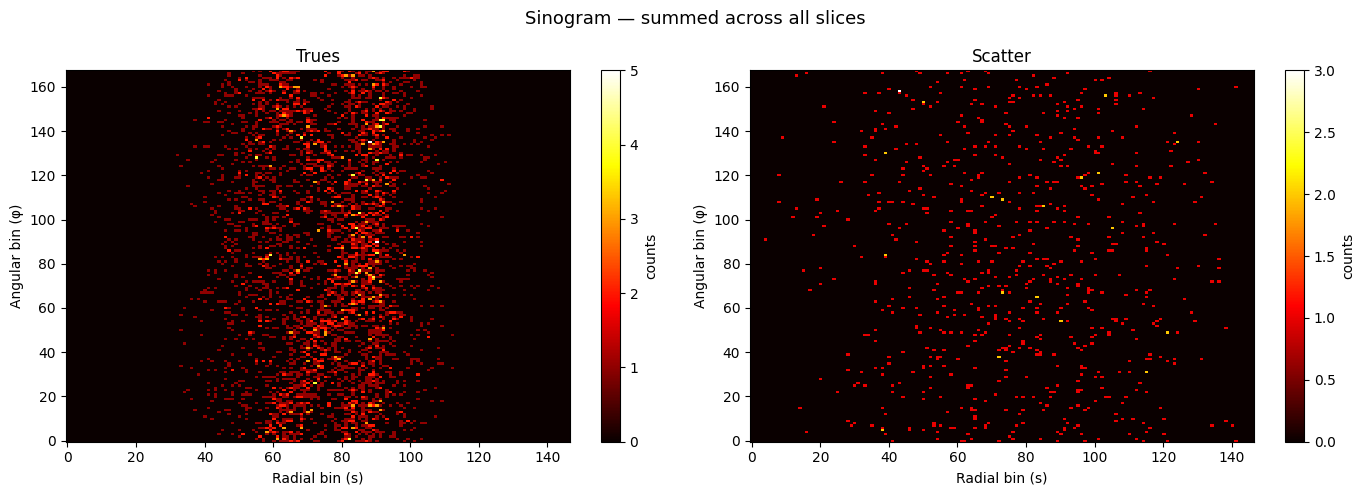

In [4]:
# ── Figure 2: Sinograms ────────────────────────────────────────────────
# # Pick a central sinogram slice (direct plane, segment 0)
# central = 1293 // 2

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig.suptitle(f"Sinogram — slice {central} (central direct plane)", fontsize=13)

# for ax, sino, label in zip(axes,
#                             [sino_trues, sino_scatter],
#                             ["Trues", "Scatter"]):
#     im = ax.imshow(sino[central], cmap="hot", interpolation="nearest",
#                    aspect="auto", origin="lower")
#     ax.set_title(label)
#     ax.set_xlabel("Radial bin (s)")
#     ax.set_ylabel("Angular bin (φ)")
#     plt.colorbar(im, ax=ax, label="counts")

# plt.tight_layout()
# plt.savefig("sinograms.png", dpi=150, bbox_inches="tight")
# plt.show()

# # Sample model is too sparse, summed all slices for better visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sinogram — summed across all slices", fontsize=13)

for ax, sino, label in zip(axes,
                            [sino_trues, sino_scatter],
                            ["Trues", "Scatter"]):
    summed = sino.sum(axis=0)   # (168, 147)
    print(f"{label} summed max: {summed.max()}, total: {summed.sum()}")
    im = ax.imshow(summed, cmap="hot", interpolation="nearest",
                   aspect="auto", origin="lower")
    ax.set_title(label)
    ax.set_xlabel("Radial bin (s)")
    ax.set_ylabel("Angular bin (φ)")
    plt.colorbar(im, ax=ax, label="counts")

plt.tight_layout()
# plt.savefig("sinograms_summed.png", dpi=150, bbox_inches="tight")
plt.show()